In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import MonthLocator, num2date
from matplotlib.ticker import FuncFormatter
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10

In [2]:
pwd

'c:\\Users\\ROHAN\\OneDrive\\Desktop\\Projects\\ML Projects\\Sales Department'

In [3]:
os.chdir(r'C:\Users\ROHAN\OneDrive\Desktop\Projects\ML Projects\Sales Department')

In [4]:
pwd

'c:\\Users\\ROHAN\\OneDrive\\Desktop\\Projects\\ML Projects\\Sales Department'

In [5]:
train_df=pd.read_csv('train.csv')
train_df

c:\Users\ROHAN\.conda\envs\FBProphet\lib\site-packages\IPython\core\interactiveshell.py:3457: DtypeWarning: Columns (7) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [6]:
train_df.shape

(1017209, 9)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [8]:
train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [10]:
train_df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [11]:
store_df=pd.read_csv('store.csv')
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [12]:
store_df.shape

(1115, 10)

In [13]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [14]:
store_df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [15]:
store_df.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [16]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

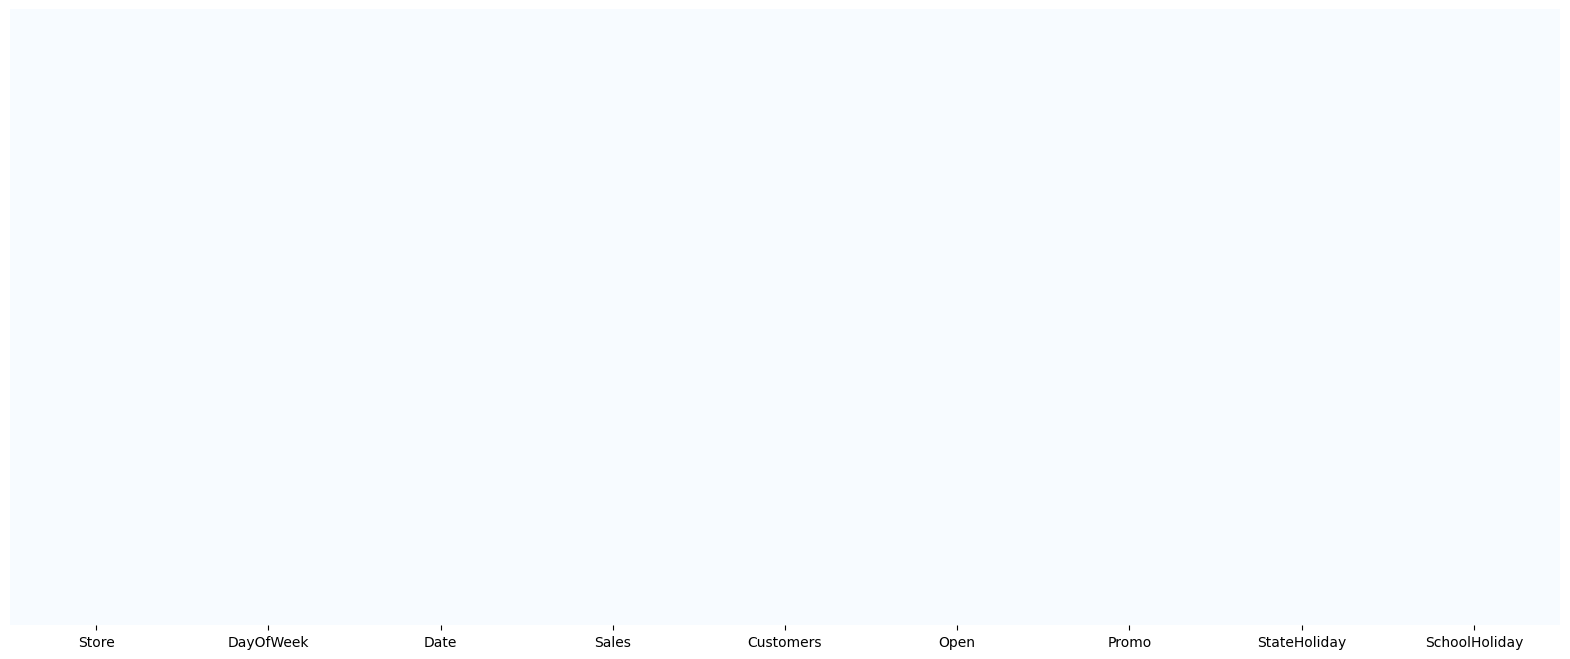

In [17]:
plt.figure(figsize=(20,8))
sns.heatmap(train_df.isnull(),yticklabels=False, cmap= 'Blues', cbar=False)
plt.show()

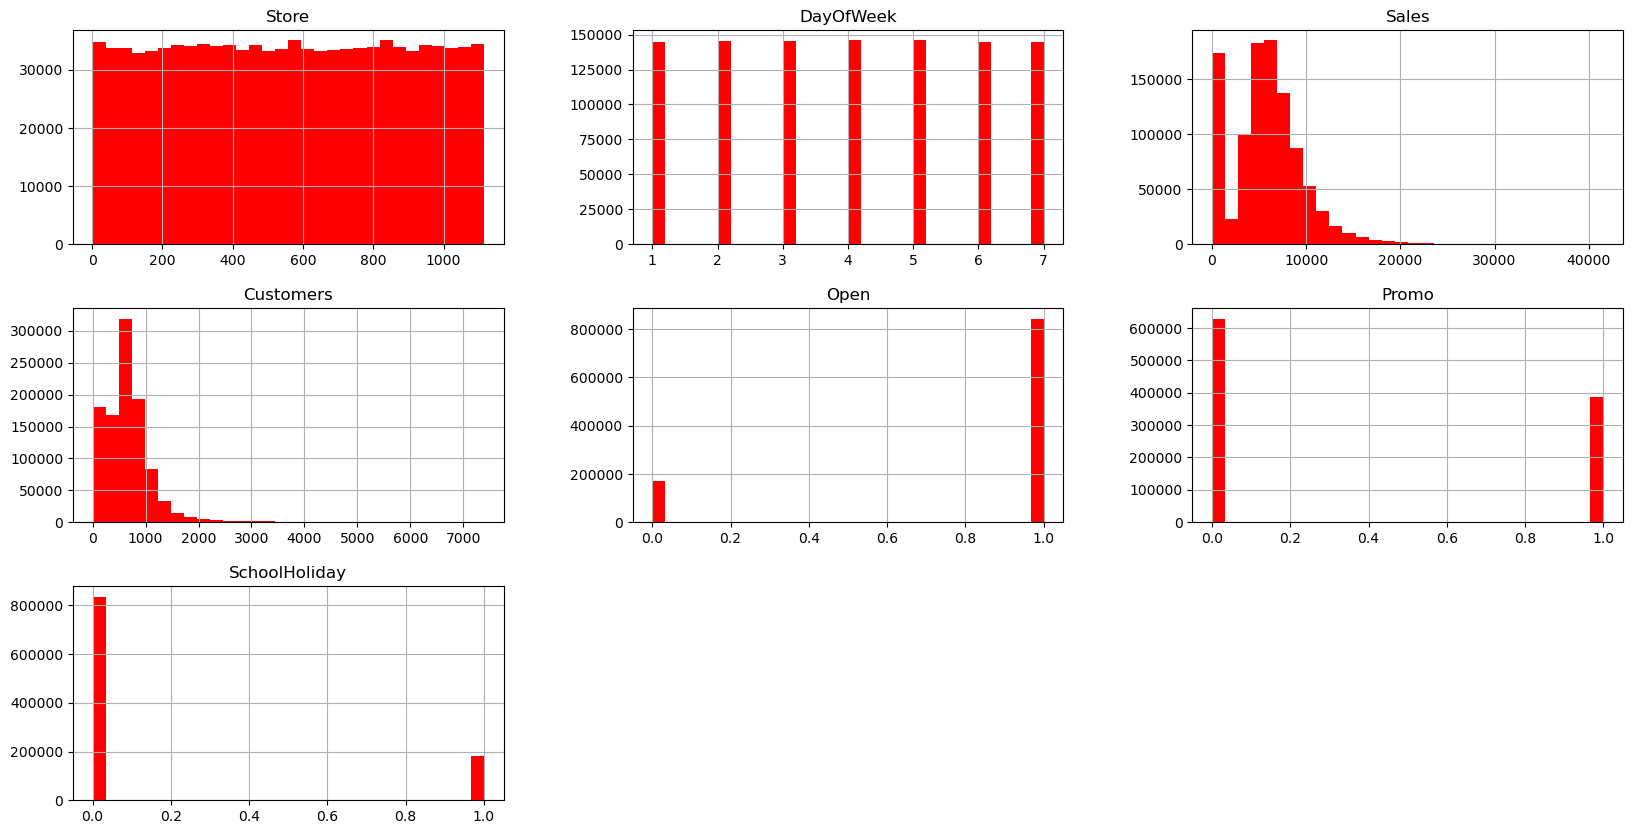

In [18]:
train_df.hist( bins=30, figsize=(20,10), color='r')
plt.show()

In [19]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [20]:
train_df['Customers'].max()

7388

In [21]:
closed_train_df=train_df[train_df['Open']==0]
closed_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
291,292,5,2015-07-31,0,0,0,1,0,1
875,876,5,2015-07-31,0,0,0,1,0,1
1406,292,4,2015-07-30,0,0,0,1,0,1
1990,876,4,2015-07-30,0,0,0,1,0,1
2521,292,3,2015-07-29,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [22]:
open_train_df=train_df[train_df['Open']==1]
open_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


In [23]:
print('Total stores=', len(train_df))
print('No. of closed stores=', len(closed_train_df))
print('No. of open stores=', len(open_train_df))

Total stores= 1017209
No. of closed stores= 172817
No. of open stores= 844392


In [24]:
train_df=train_df[train_df['Open']==1]
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


In [25]:
train_df.drop(['Open'], axis=1, inplace=True)
train_df

c:\Users\ROHAN\.conda\envs\FBProphet\lib\site-packages\pandas\core\frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1
...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1
1016827,733,2,2013-01-01,10765,2377,0,a,1
1016863,769,2,2013-01-01,5035,1248,0,a,1
1017042,948,2,2013-01-01,4491,1039,0,a,1


In [26]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

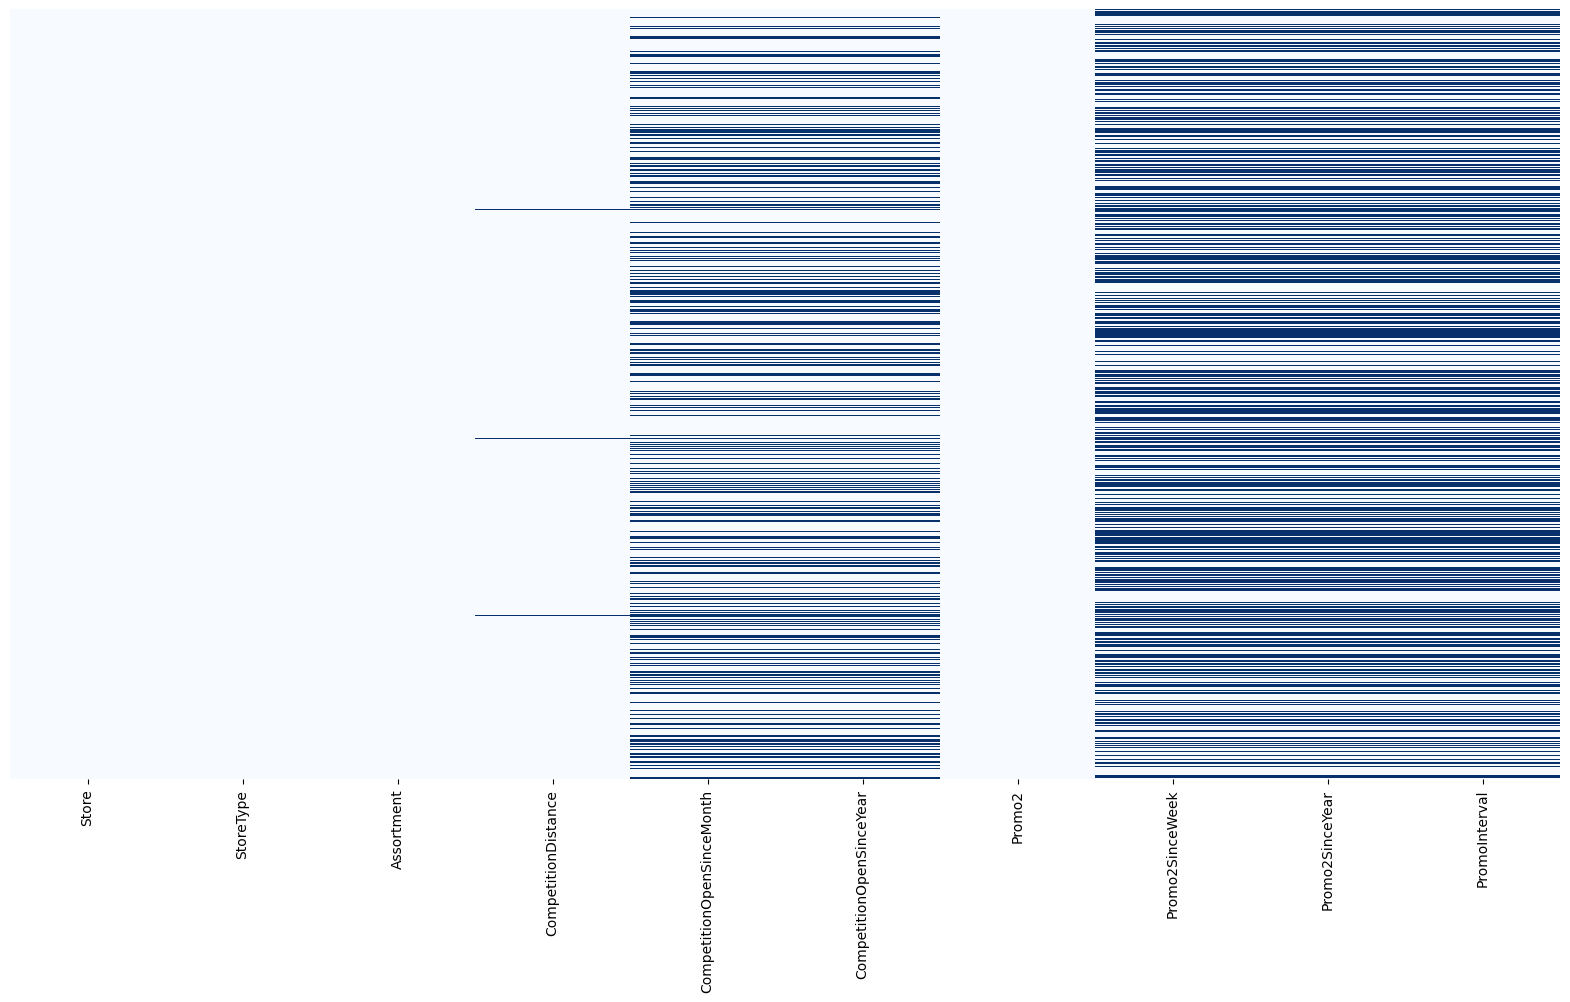

In [27]:
plt.figure(figsize=(20,10))
sns.heatmap(store_df.isnull(), yticklabels=False, cbar=False, cmap='Blues')
plt.show()

In [28]:
store_df[store_df['CompetitionDistance'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [29]:
store_df[store_df['CompetitionOpenSinceMonth'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [30]:
store_df[store_df['Promo2']==0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [31]:
store_df[store_df['CompetitionOpenSinceMonth'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [32]:
store_df[store_df['CompetitionOpenSinceYear'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [33]:
str_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']

In [34]:
for str in str_cols:
    store_df[str].fillna(0, inplace=True)

In [35]:
store_df.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          3
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

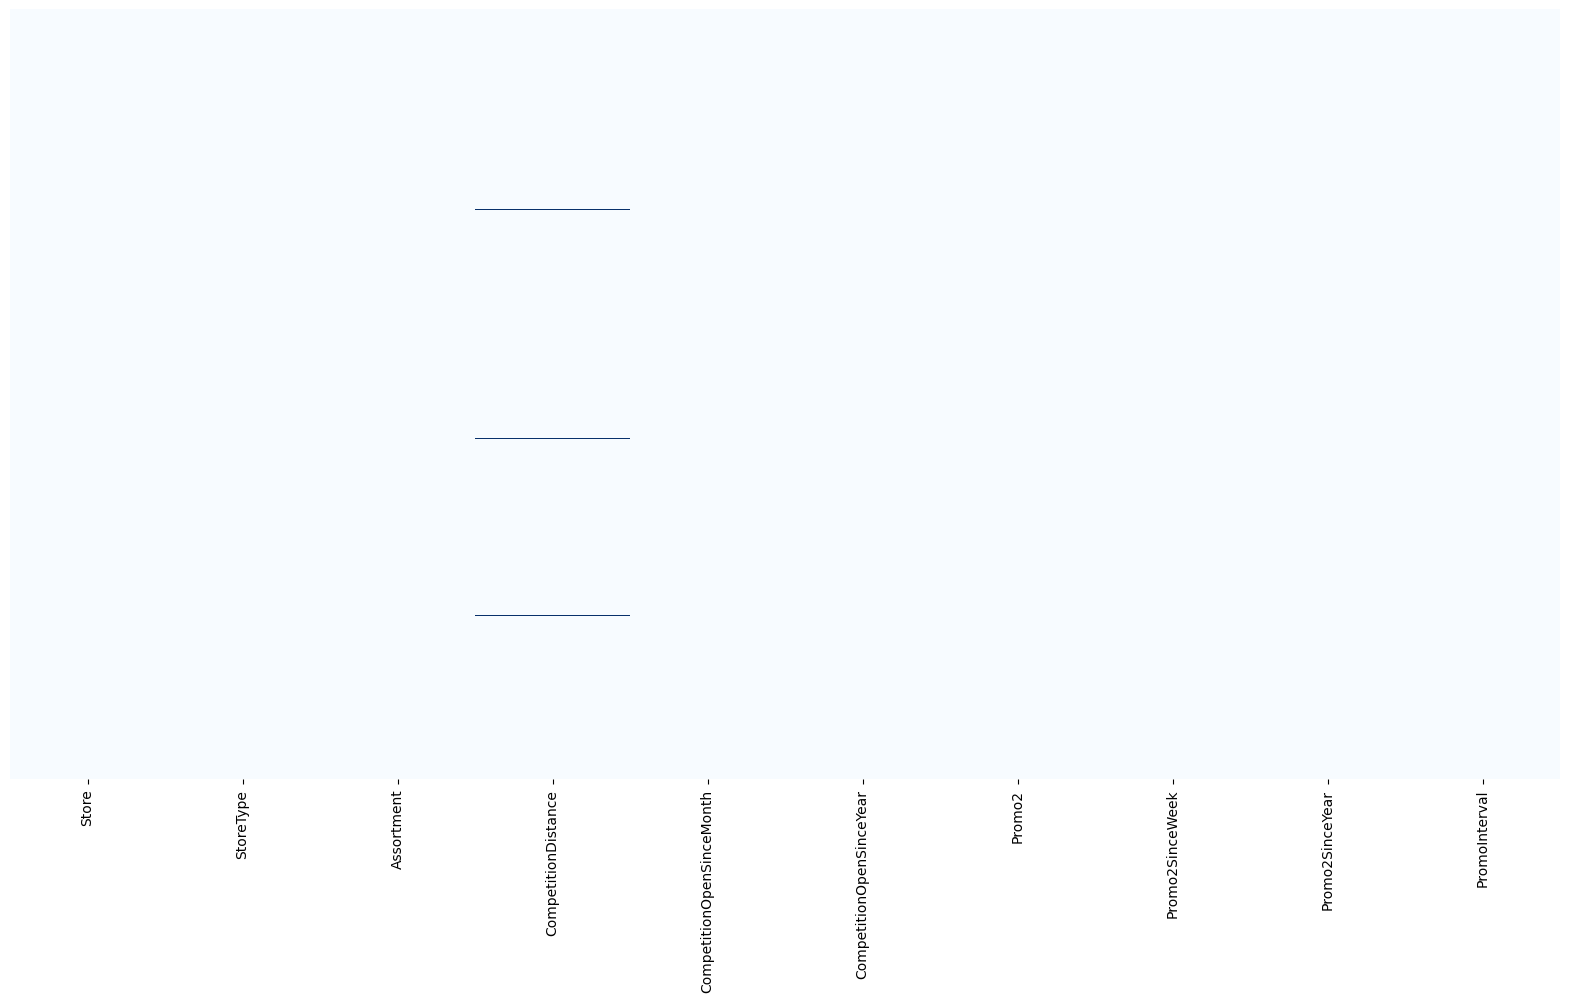

In [36]:
sns.heatmap(store_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()


In [37]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,0.0,0.0,0
1112,1113,a,c,9260.0,0.0,0.0,0,0.0,0.0,0
1113,1114,a,c,870.0,0.0,0.0,0,0.0,0.0,0


In [38]:
comp_dist=store_df['CompetitionDistance'].mean()
comp_dist

5404.901079136691

In [39]:
store_df['CompetitionDistance'].fillna(comp_dist,  inplace=True)

In [40]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,0.0,0.0,0
1112,1113,a,c,9260.0,0.0,0.0,0,0.0,0.0,0
1113,1114,a,c,870.0,0.0,0.0,0,0.0,0.0,0


In [41]:
store_df.isna().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

<AxesSubplot:>

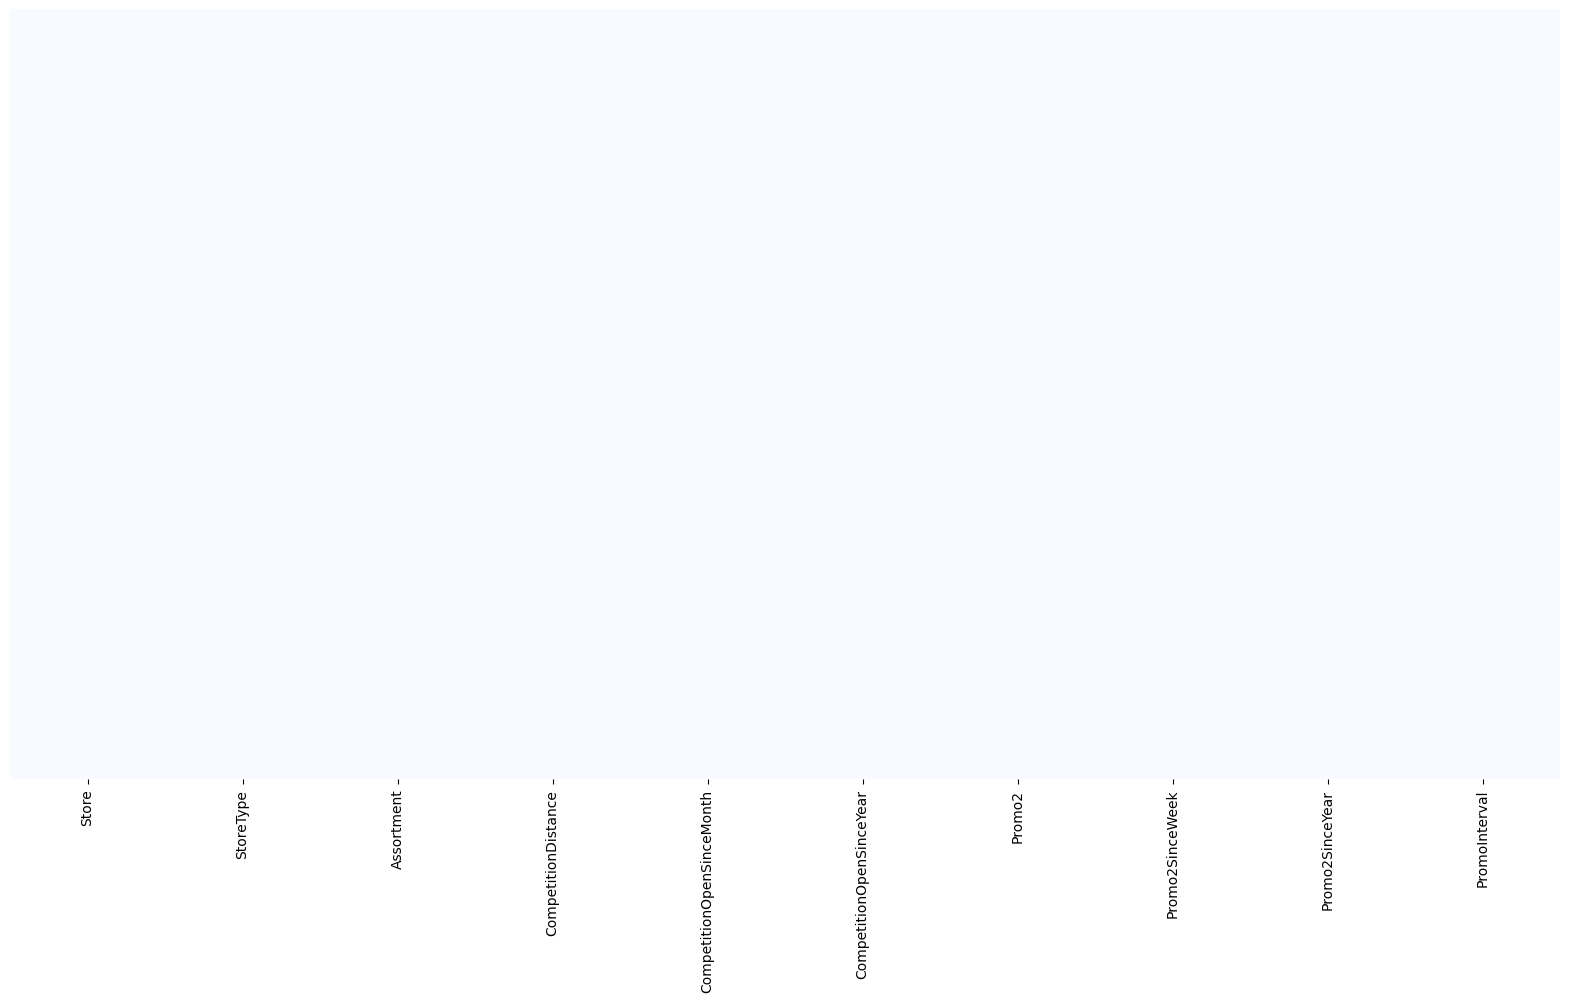

In [42]:
sns.heatmap(store_df.isnull(), yticklabels=False, cbar=False, cmap='Blues')

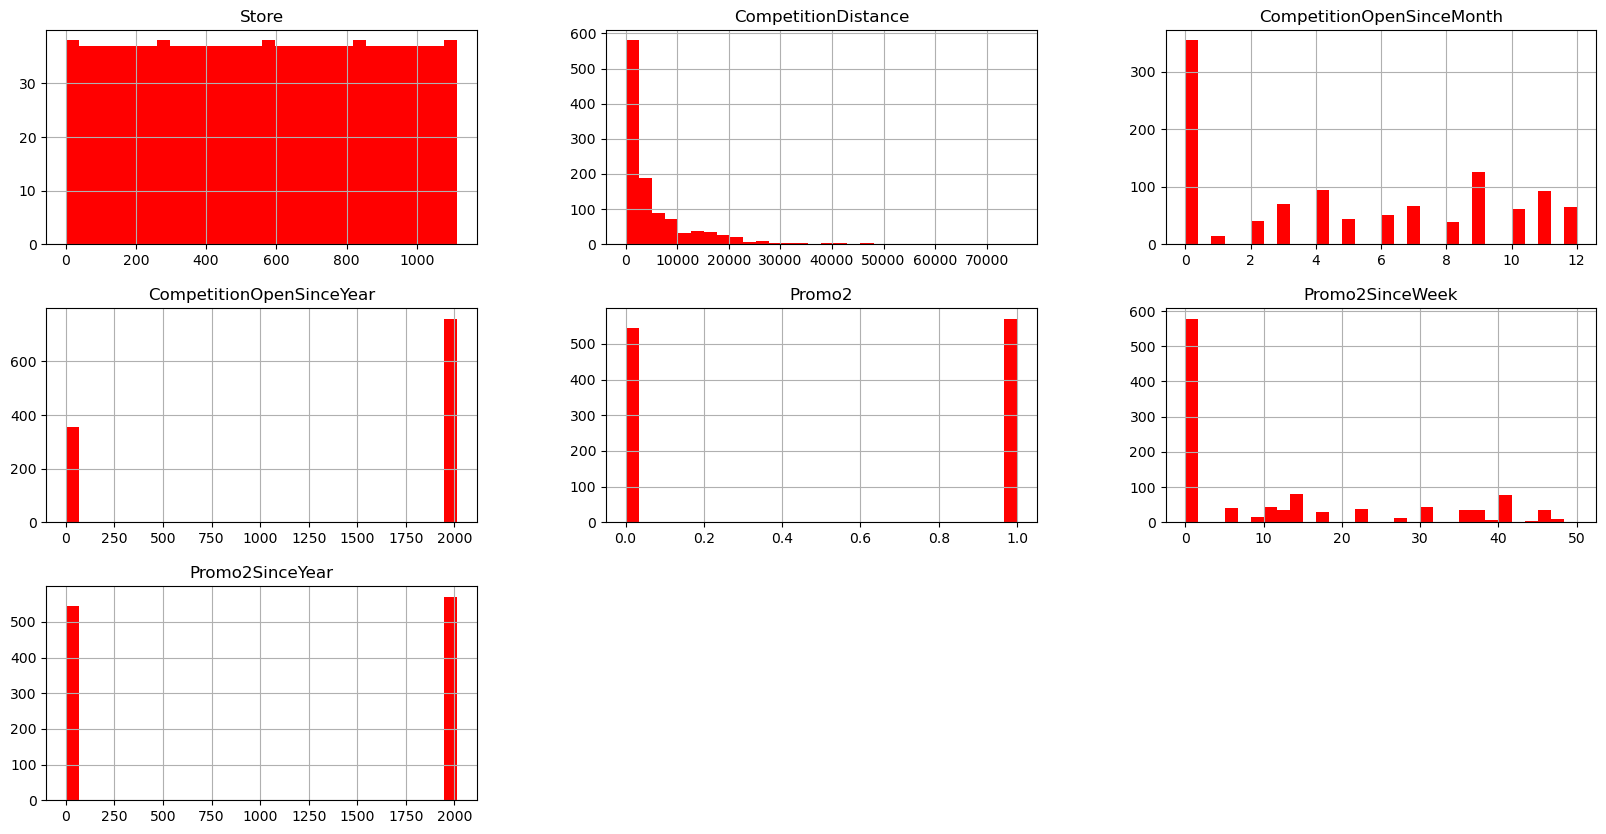

In [43]:
store_df.hist(bins=30, color='r')
plt.show()

In [44]:
merged_df=pd.merge(train_df, store_df, how='inner', on='Store')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,292,1,2013-01-07,9291,1002,1,0,0,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0
844388,292,6,2013-01-05,2748,340,0,0,0,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0
844389,292,5,2013-01-04,4202,560,0,0,1,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0
844390,292,4,2013-01-03,4580,662,0,0,1,a,a,1100.0,6.0,2009.0,0,0.0,0.0,0


In [45]:
merged_df.to_csv('merged_data.csv', index=False)

In [47]:
correlations = merged_df.corr()['Sales'].sort_values()
correlations

DayOfWeek                   -0.178736
Promo2SinceYear             -0.127621
Promo2                      -0.127596
Promo2SinceWeek             -0.058476
CompetitionDistance         -0.036343
CompetitionOpenSinceMonth   -0.018370
CompetitionOpenSinceYear     0.005266
Store                        0.007710
SchoolHoliday                0.038617
Promo                        0.368145
Customers                    0.823597
Sales                        1.000000
Name: Sales, dtype: float64

In [48]:
correlations = merged_df.corr()
correlations

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
Store,1.000000,0.000346,0.007710,0.033977,-0.000012,0.000512,-0.027031,-0.032555,-0.008152,0.007736,0.010857,0.007768
DayOfWeek,0.000346,1.000000,-0.178736,-0.097266,-0.289265,-0.139315,0.005528,-0.000834,-0.001303,-0.003241,-0.002736,-0.003238
Sales,0.007710,-0.178736,1.000000,0.823597,0.368145,0.038617,-0.036343,-0.018370,0.005266,-0.127596,-0.058476,-0.127621
Customers,0.033977,-0.097266,0.823597,1.000000,0.182846,0.024902,-0.148362,-0.021006,0.001666,-0.202232,-0.130841,-0.202204
Promo,-0.000012,-0.289265,0.368145,0.182846,1.000000,0.028964,-0.002390,0.000711,0.000990,-0.000324,-0.000802,-0.000326
SchoolHoliday,0.000512,-0.139315,0.038617,0.024902,0.028964,1.000000,-0.004274,-0.000131,0.000126,-0.008245,-0.008062,-0.008248
CompetitionDistance,-0.027031,0.005528,-0.036343,-0.148362,-0.002390,-0.004274,1.000000,-0.033264,-0.002713,-0.141784,-0.124703,-0.141847
CompetitionOpenSinceMonth,-0.032555,-0.000834,-0.018370,-0.021006,0.000711,-0.000131,-0.033264,1.000000,0.785326,-0.082561,-0.109522,-0.082488
CompetitionOpenSinceYear,-0.008152,-0.001303,0.005266,0.001666,0.000990,0.000126,-0.002713,0.785326,1.000000,-0.098571,-0.125080,-0.098503
Promo2,0.007736,-0.003241,-0.127596,-0.202232,-0.000324,-0.008245,-0.141784,-0.082561,-0.098571,1.000000,0.759523,0.999999


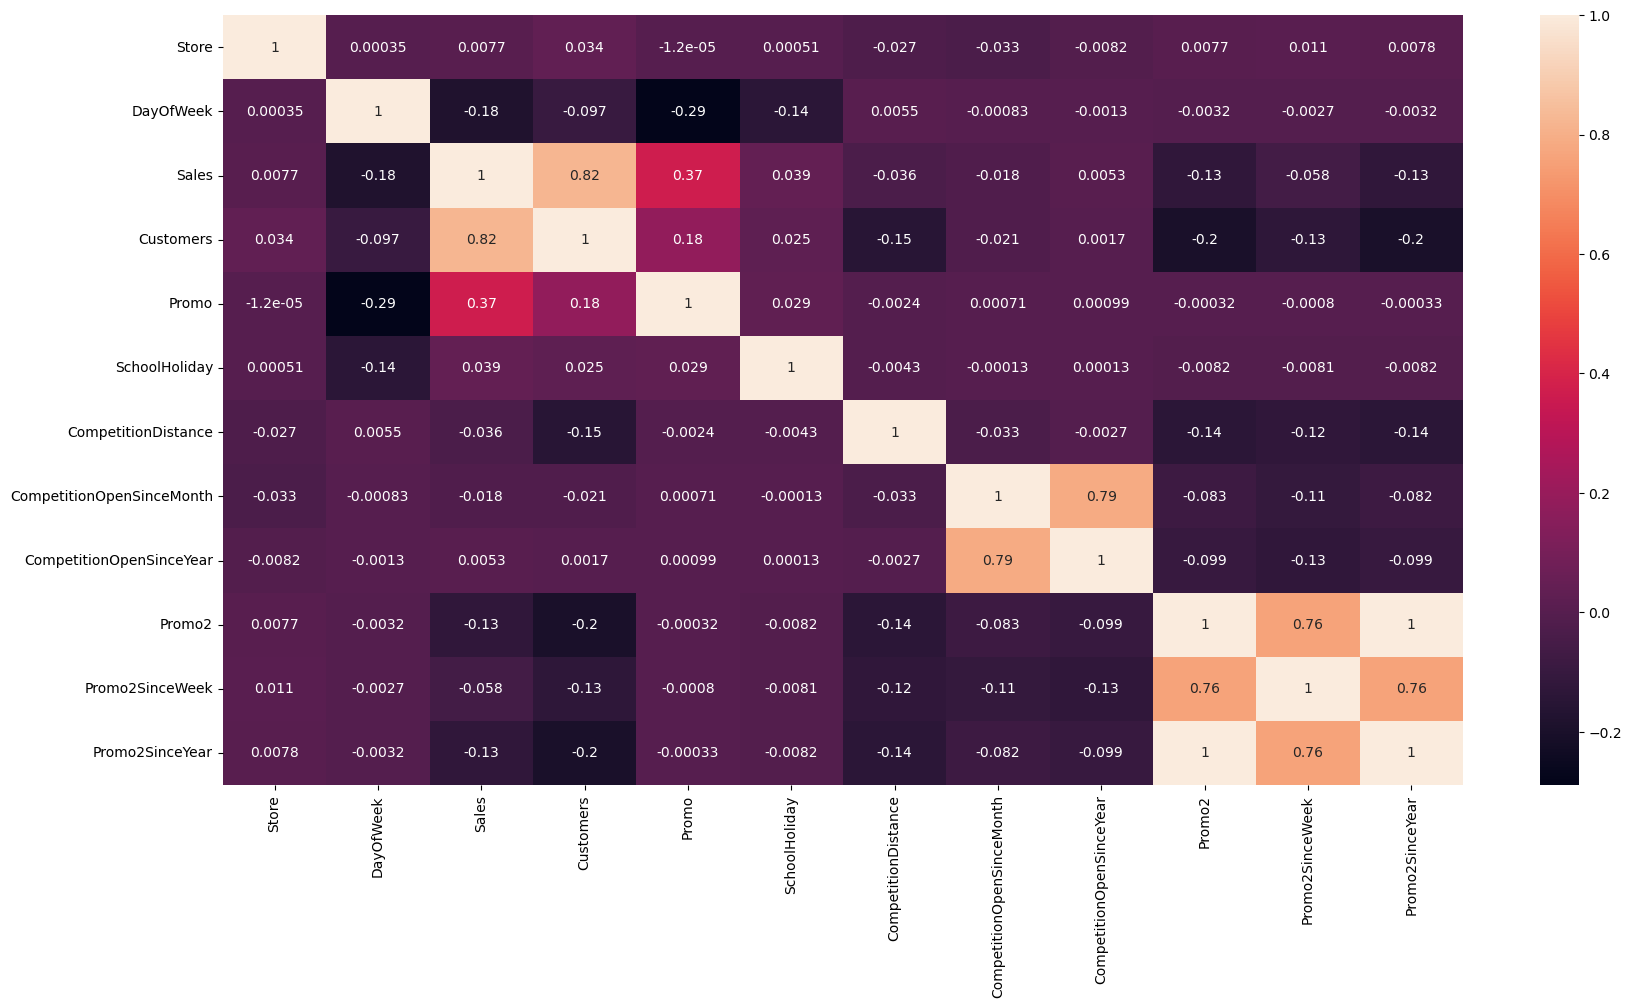

In [49]:
sns.heatmap(correlations, annot=True)
plt.show()

In [50]:
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0


In [51]:
merged_df['Year']=pd.DatetimeIndex(merged_df['Date']).year
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015


In [52]:
merged_df['Month']=pd.DatetimeIndex(merged_df['Date']).month
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7


In [53]:
merged_df['Day']=pd.DatetimeIndex(merged_df['Date']).day
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,30
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,29
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,28
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,27


In [54]:
avg_sales_per_month=merged_df.groupby('Month')['Sales'].mean()
avg_sales_per_month

Month
1     6563.690444
2     6589.165535
3     6976.412026
4     7046.228420
5     7106.453154
6     7000.978190
7     6952.682125
8     6648.984654
9     6546.343035
10    6602.843354
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64

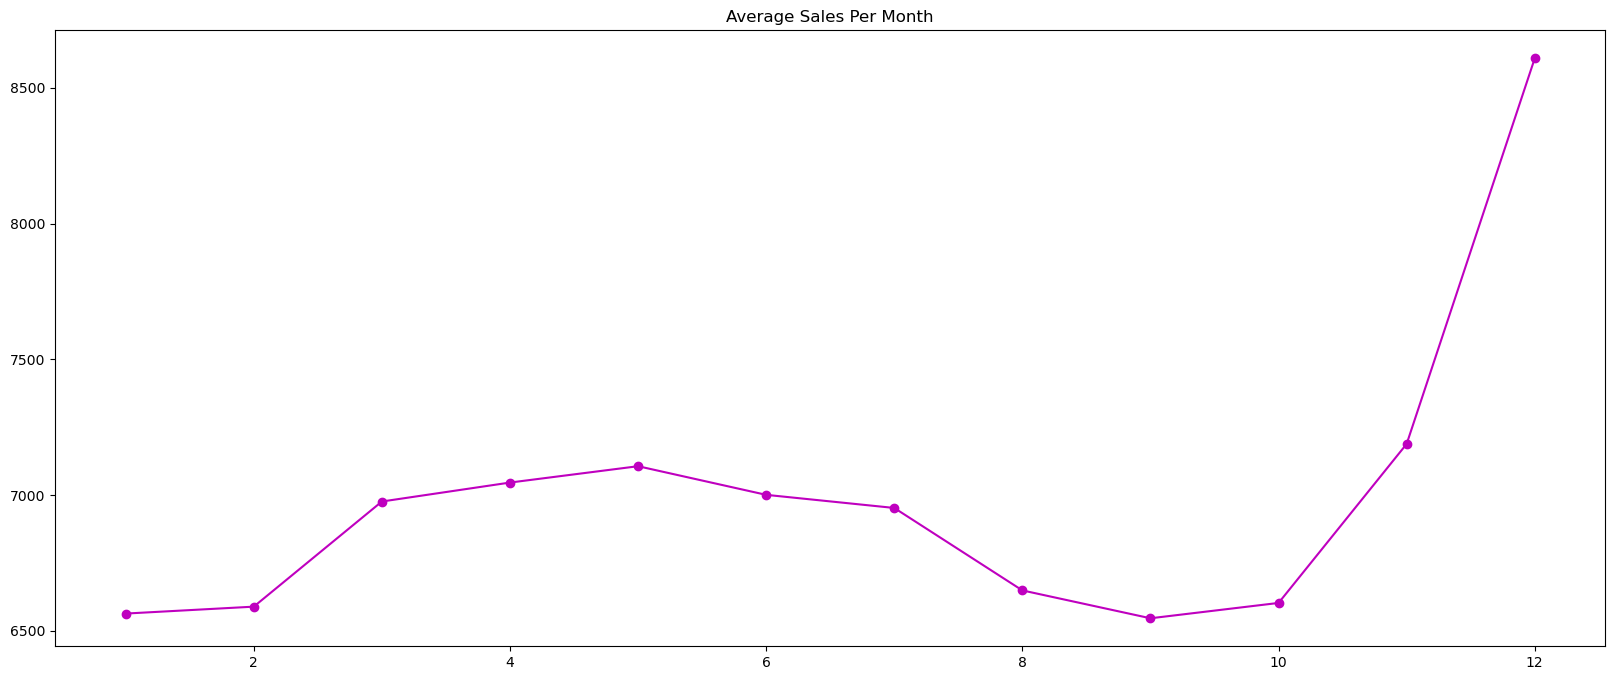

In [55]:
plt.figure(figsize=(20,8))
plt.plot(avg_sales_per_month, c='m', marker='o')
plt.title('Average Sales Per Month')
plt.show()

In [56]:
avg_customers_per_month=merged_df.groupby('Month')['Customers'].mean()
avg_customers_per_month

Month
1     722.514749
2     731.504792
3     759.081600
4     774.271806
5     779.290214
6     759.277357
7     752.745522
8     750.384706
9     745.613988
10    752.573557
11    782.671543
12    886.630385
Name: Customers, dtype: float64

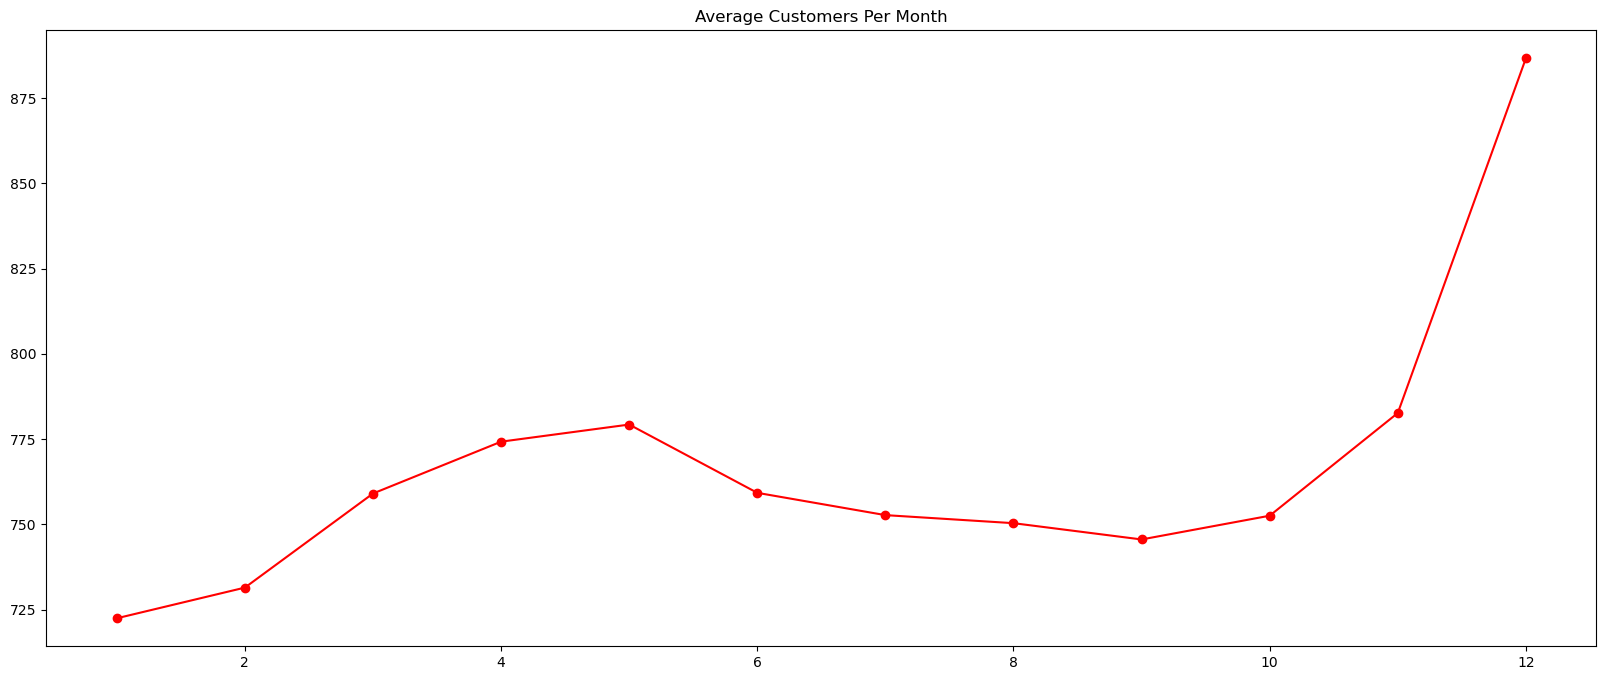

In [57]:
plt.figure(figsize=(20,8))
plt.plot(avg_customers_per_month, c='r', marker='o')
plt.title('Average Customers Per Month')
plt.show()

In [58]:
avg_sales_per_day=merged_df.groupby('Day')['Sales'].mean()
avg_sales_per_day

Day
1     8053.674102
2     7987.452335
3     7765.296991
4     7745.844134
5     7554.982112
6     7149.914351
7     7101.113826
8     6785.121061
9     6499.276895
10    6429.182961
11    6087.881843
12    6186.034047
13    6570.115406
14    6606.648700
15    7018.545523
16    7314.079684
17    7283.898949
18    7340.267275
19    7115.279322
20    6955.004553
21    6693.696159
22    6544.690081
23    6498.037037
24    5915.626283
25    5967.839608
26    6189.771018
27    6636.996208
28    6943.025241
29    7512.799109
30    8354.463914
31    7577.234928
Name: Sales, dtype: float64

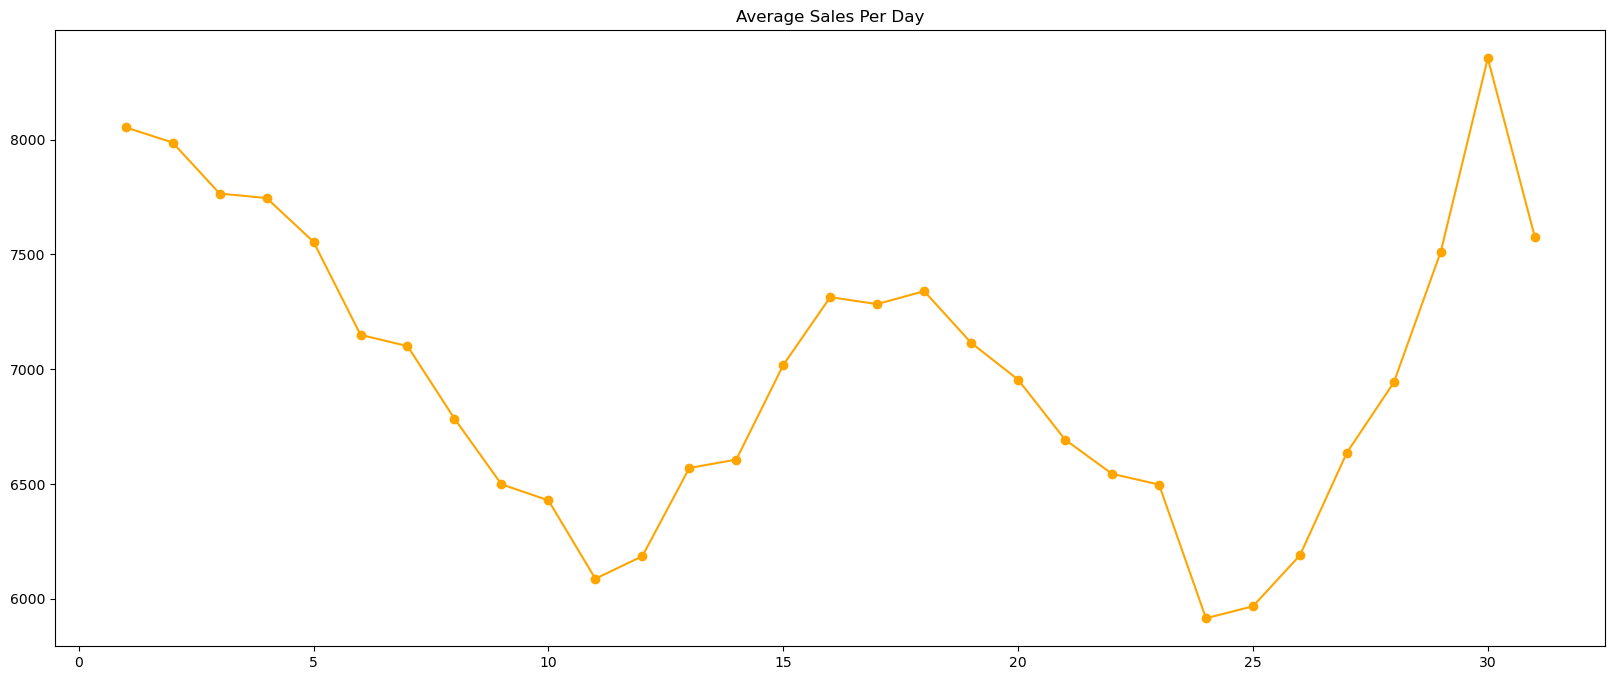

In [59]:
plt.figure(figsize=(20,8))
plt.plot(avg_sales_per_day, c='orange', marker='o')
plt.title('Average Sales Per Day')
plt.show()

In [60]:
avg_customers_per_day=merged_df.groupby('Day')['Customers'].mean()
avg_customers_per_day

Day
1     846.284593
2     842.344108
3     818.100766
4     819.085296
5     802.752484
6     778.836139
7     776.275080
8     757.211580
9     730.633183
10    735.835861
11    707.363899
12    712.577910
13    738.660208
14    738.946981
15    763.165918
16    778.993083
17    785.059423
18    784.980902
19    774.986834
20    759.847311
21    742.814287
22    738.651815
23    739.939982
24    686.380109
25    692.722889
26    707.625764
27    733.561428
28    757.671484
29    789.575525
30    861.253704
31    786.980533
Name: Customers, dtype: float64

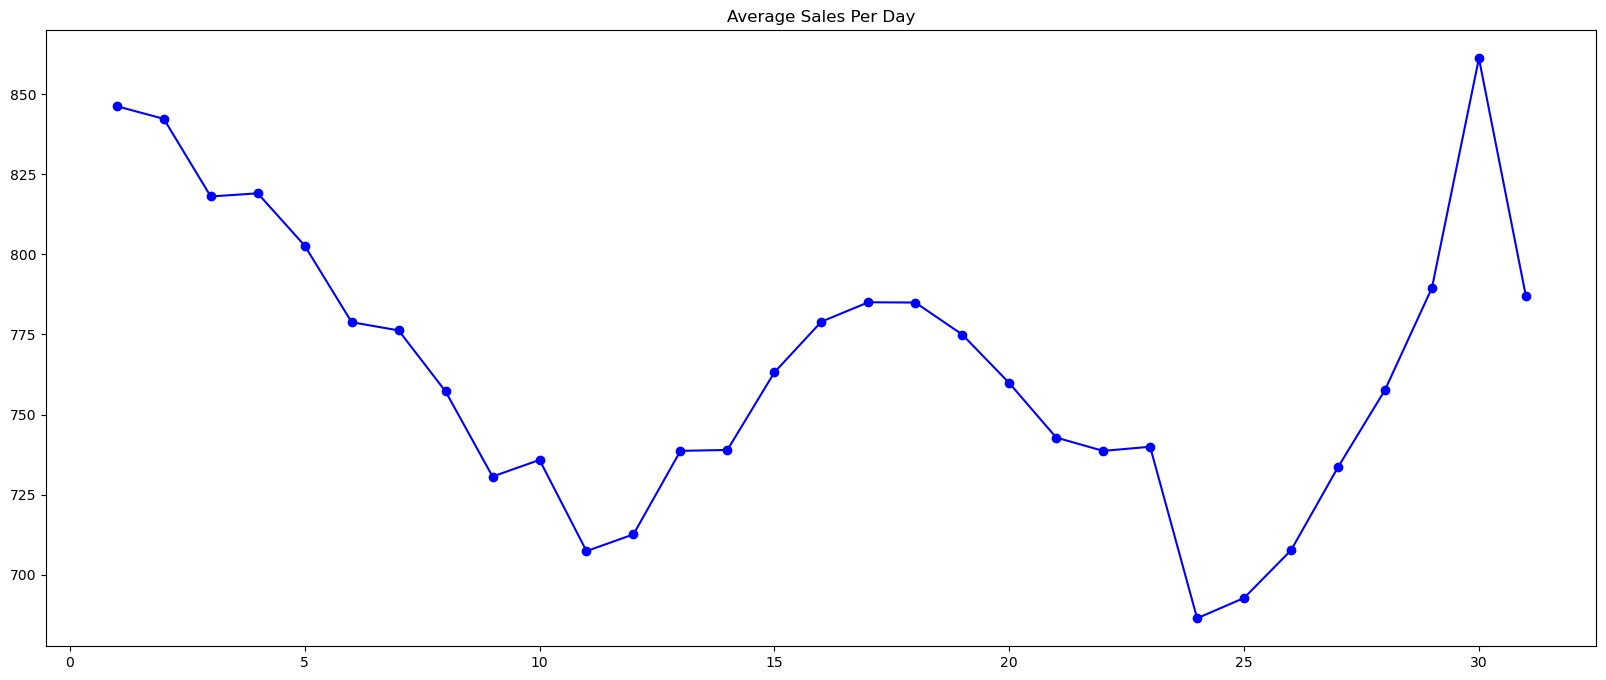

In [61]:
plt.figure(figsize=(20,8))
plt.plot(avg_customers_per_day, c='blue', marker='o')
plt.title('Average Sales Per Day')
plt.show()

In [62]:
avg_sales_per_day_of_week=merged_df.groupby('DayOfWeek')['Sales'].mean()
avg_sales_per_day_of_week

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64

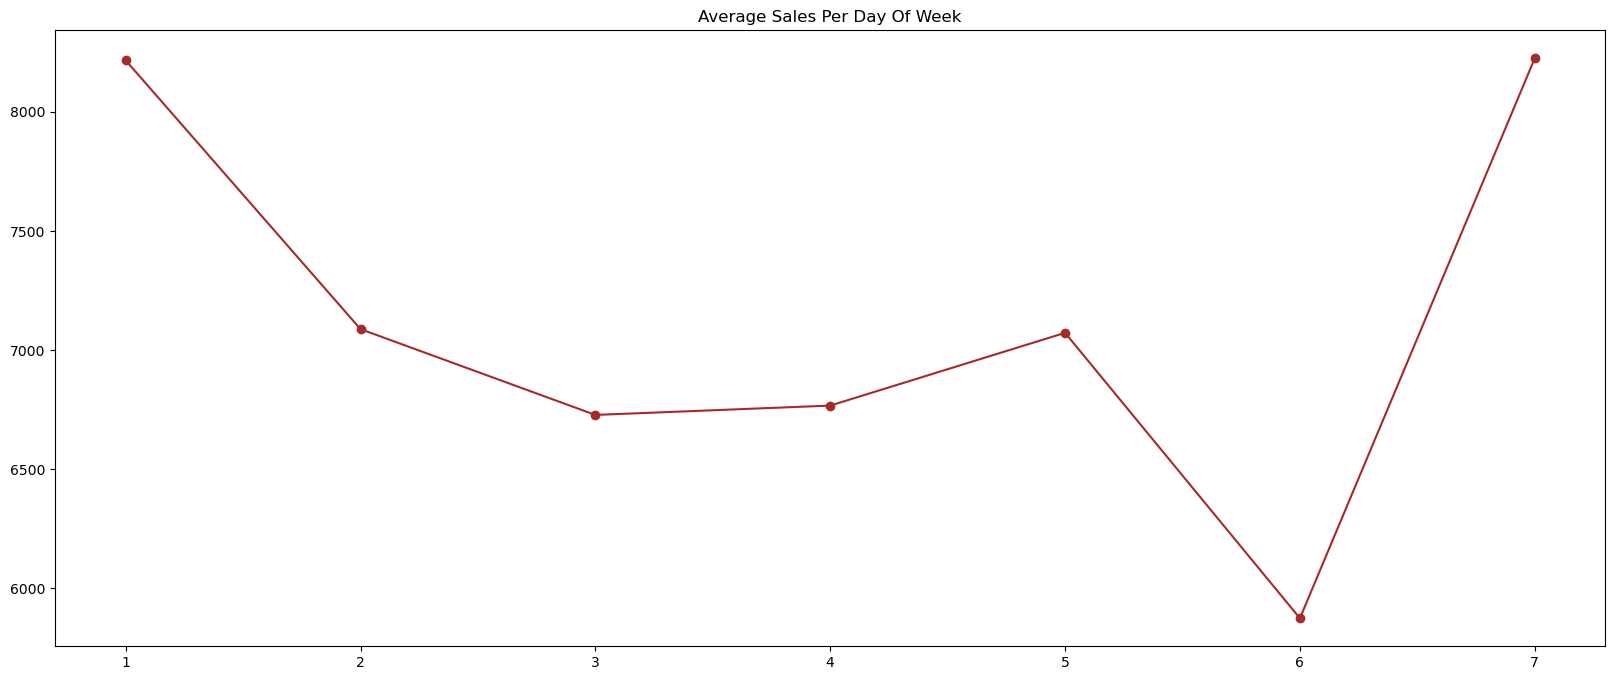

In [63]:
plt.figure(figsize=(20,8))
plt.plot(avg_sales_per_day_of_week, c='brown', marker='o')
plt.title('Average Sales Per Day Of Week')
plt.show()

In [64]:
avg_customers_per_day_of_week=merged_df.groupby('DayOfWeek')['Customers'].mean()
avg_customers_per_day_of_week

DayOfWeek
1     855.444984
2     769.986753
3     740.598876
4     755.569784
5     781.771639
6     660.177526
7    1441.532424
Name: Customers, dtype: float64

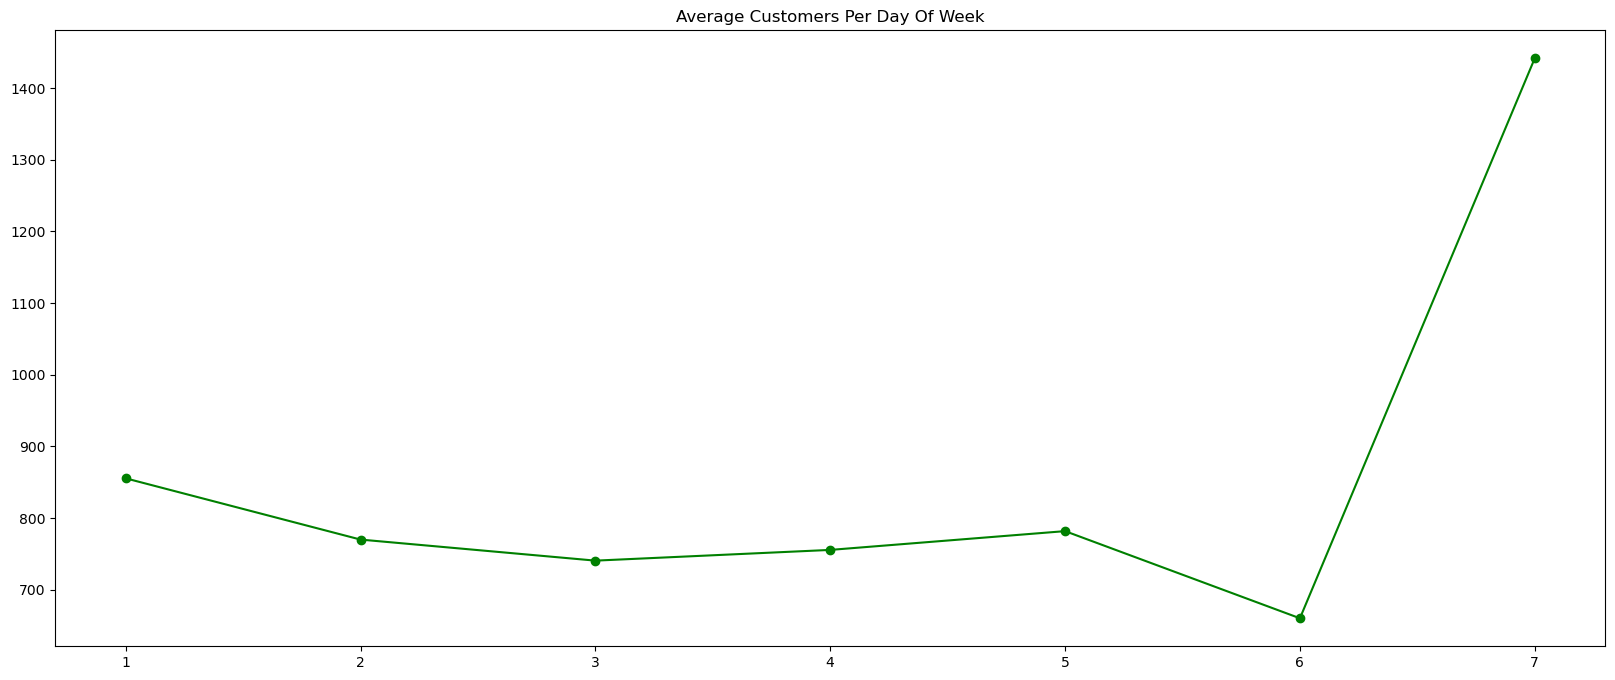

In [65]:
plt.figure(figsize=(20,8))
plt.plot(avg_customers_per_day_of_week, c='green', marker='o')
plt.title('Average Customers Per Day Of Week')
plt.show()

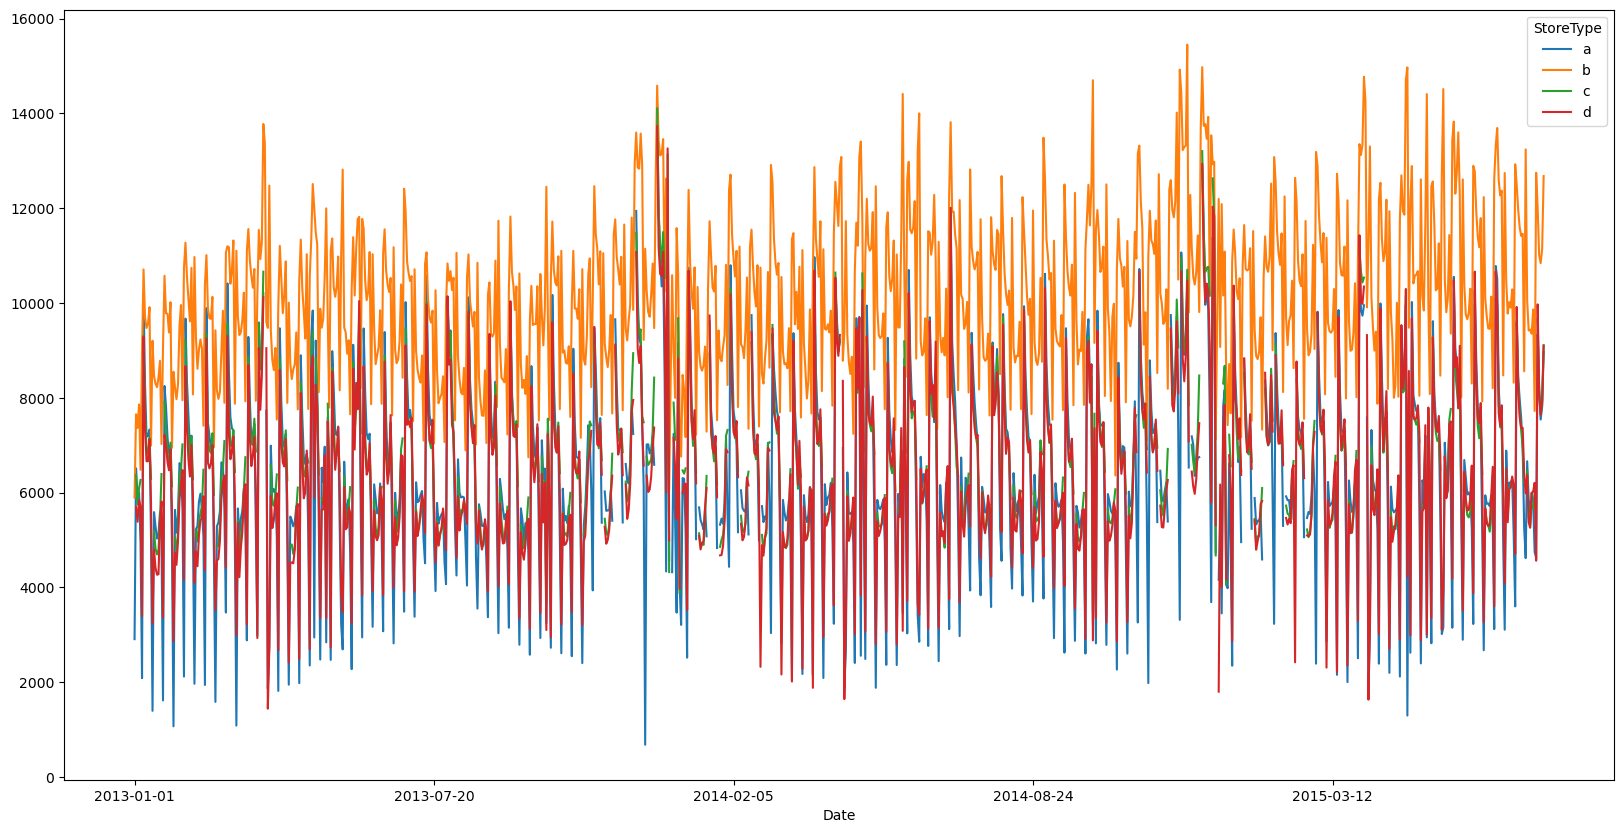

In [66]:
fig, ax = plt.subplots(figsize=(20,10))
merged_df.groupby(['Date','StoreType']).mean(numeric_only=True)['Sales'].unstack().plot(ax=ax)
plt.show()


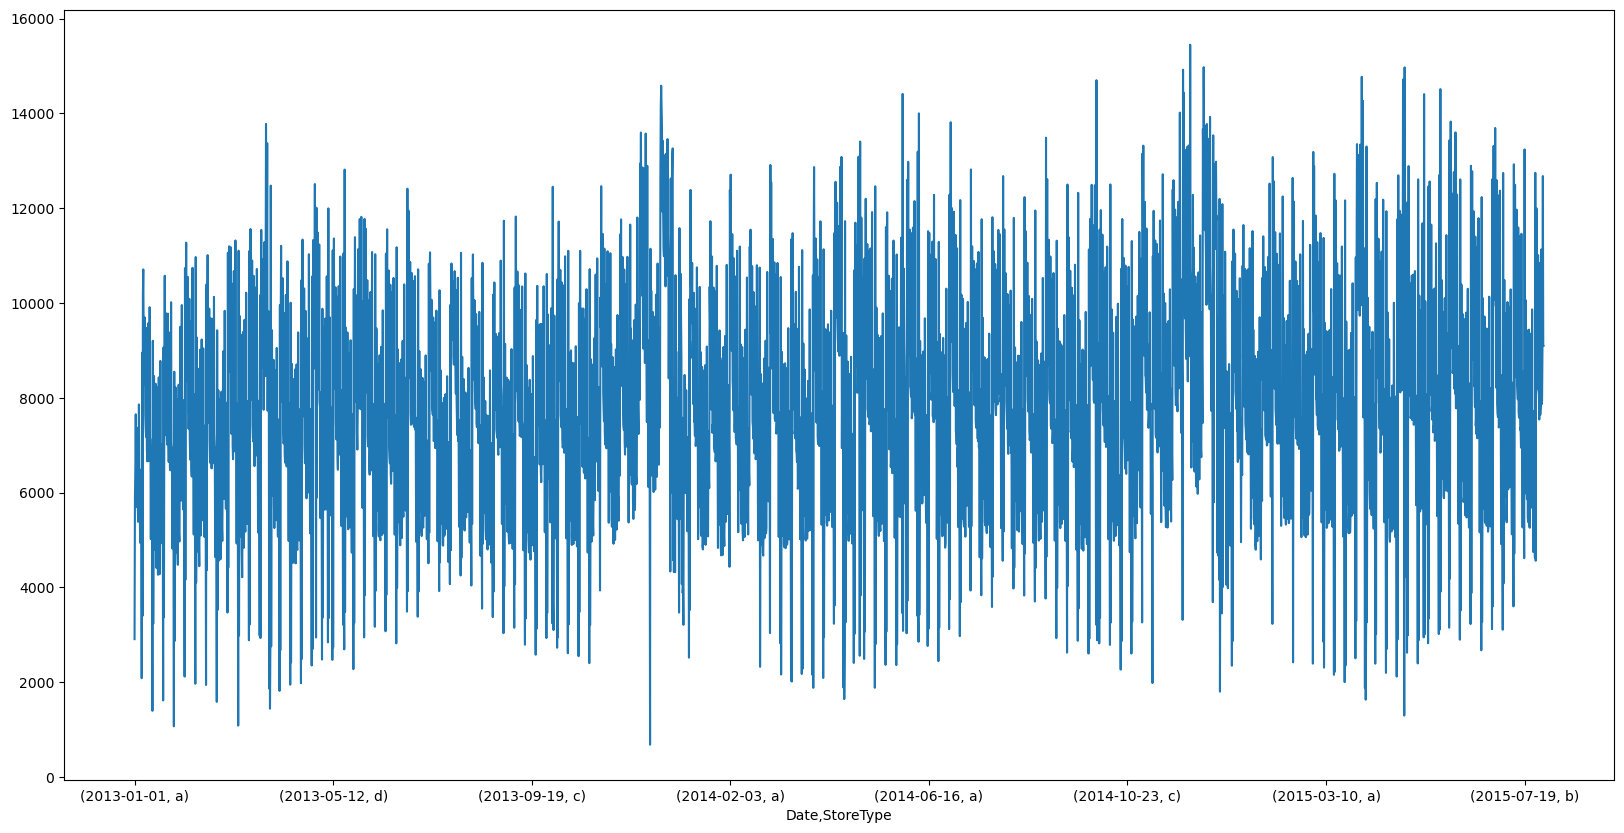

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))
merged_df.groupby(['Date','StoreType']).mean()['Sales'].plot(ax=ax)
plt.show()


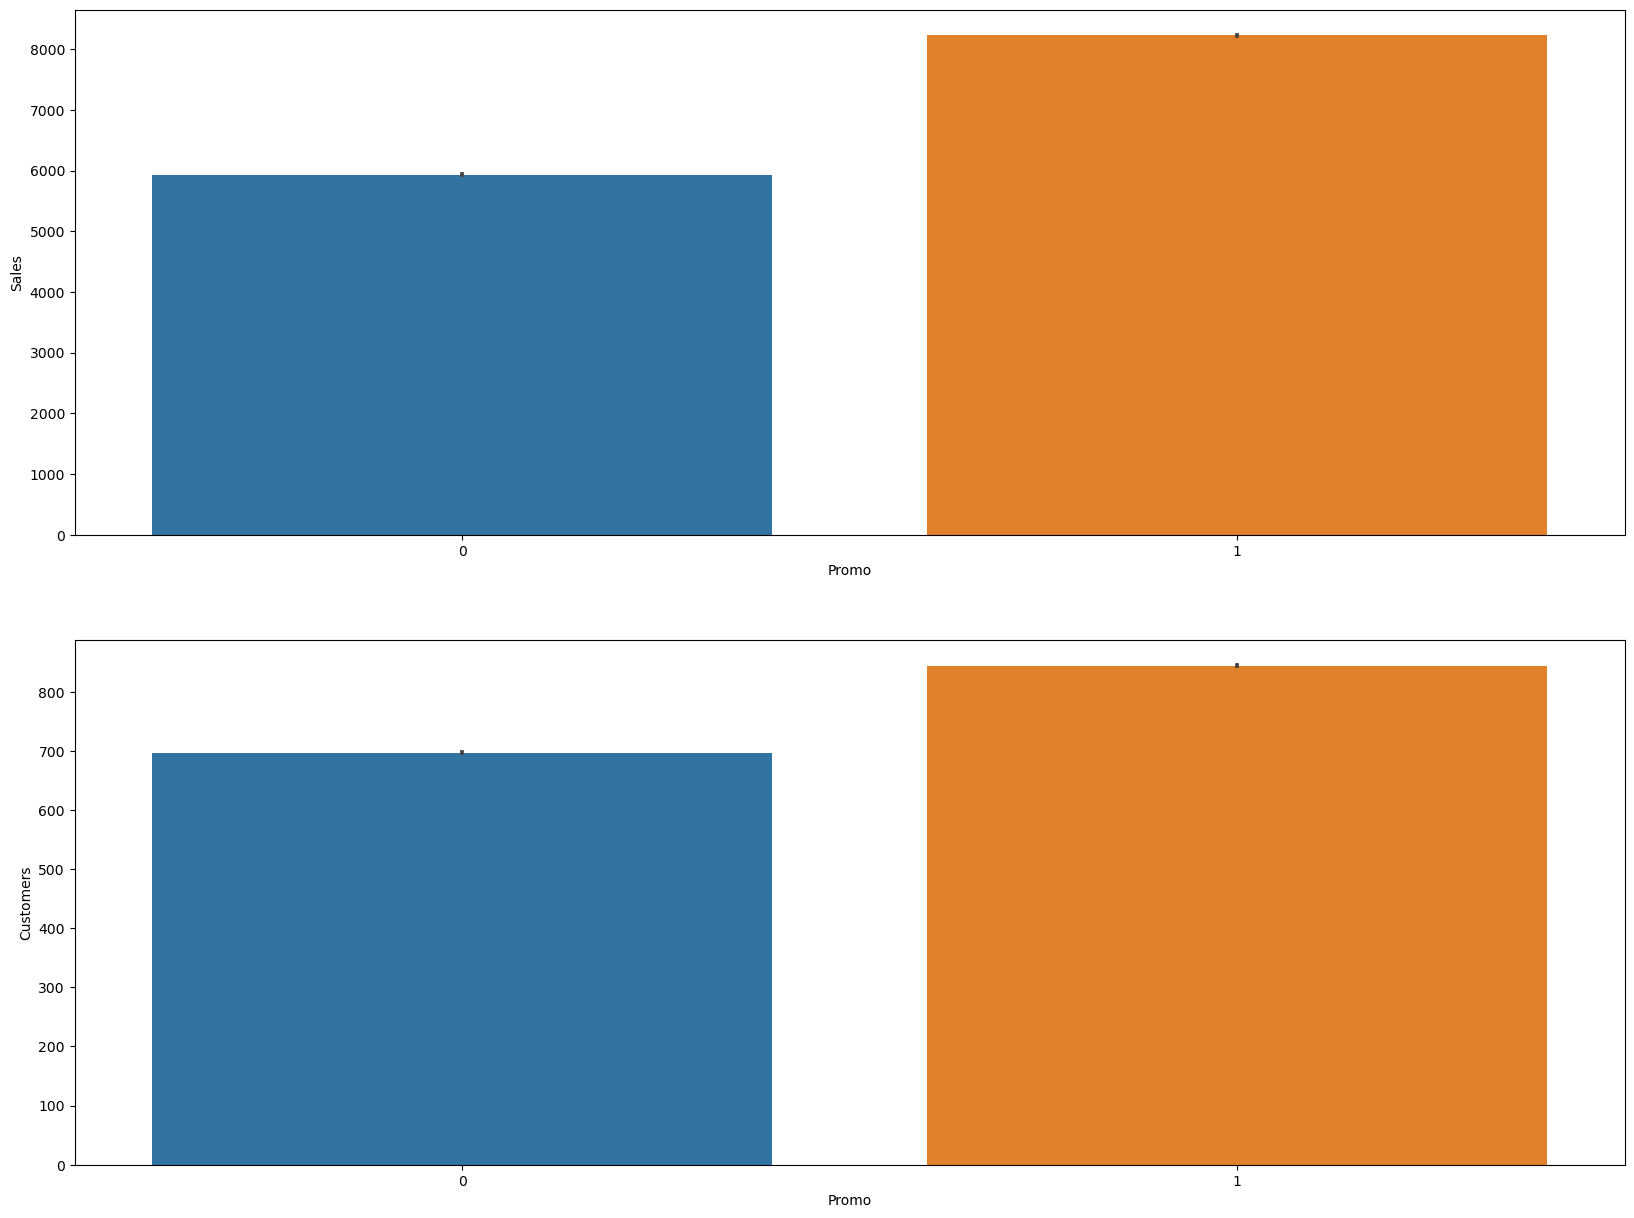

In [68]:
plt.figure(figsize=(20,15))
plt.subplot(211)
sns.barplot(x='Promo', y='Sales', data=merged_df)
plt.subplot(212)
sns.barplot(x='Promo', y='Customers', data= merged_df)
plt.show()


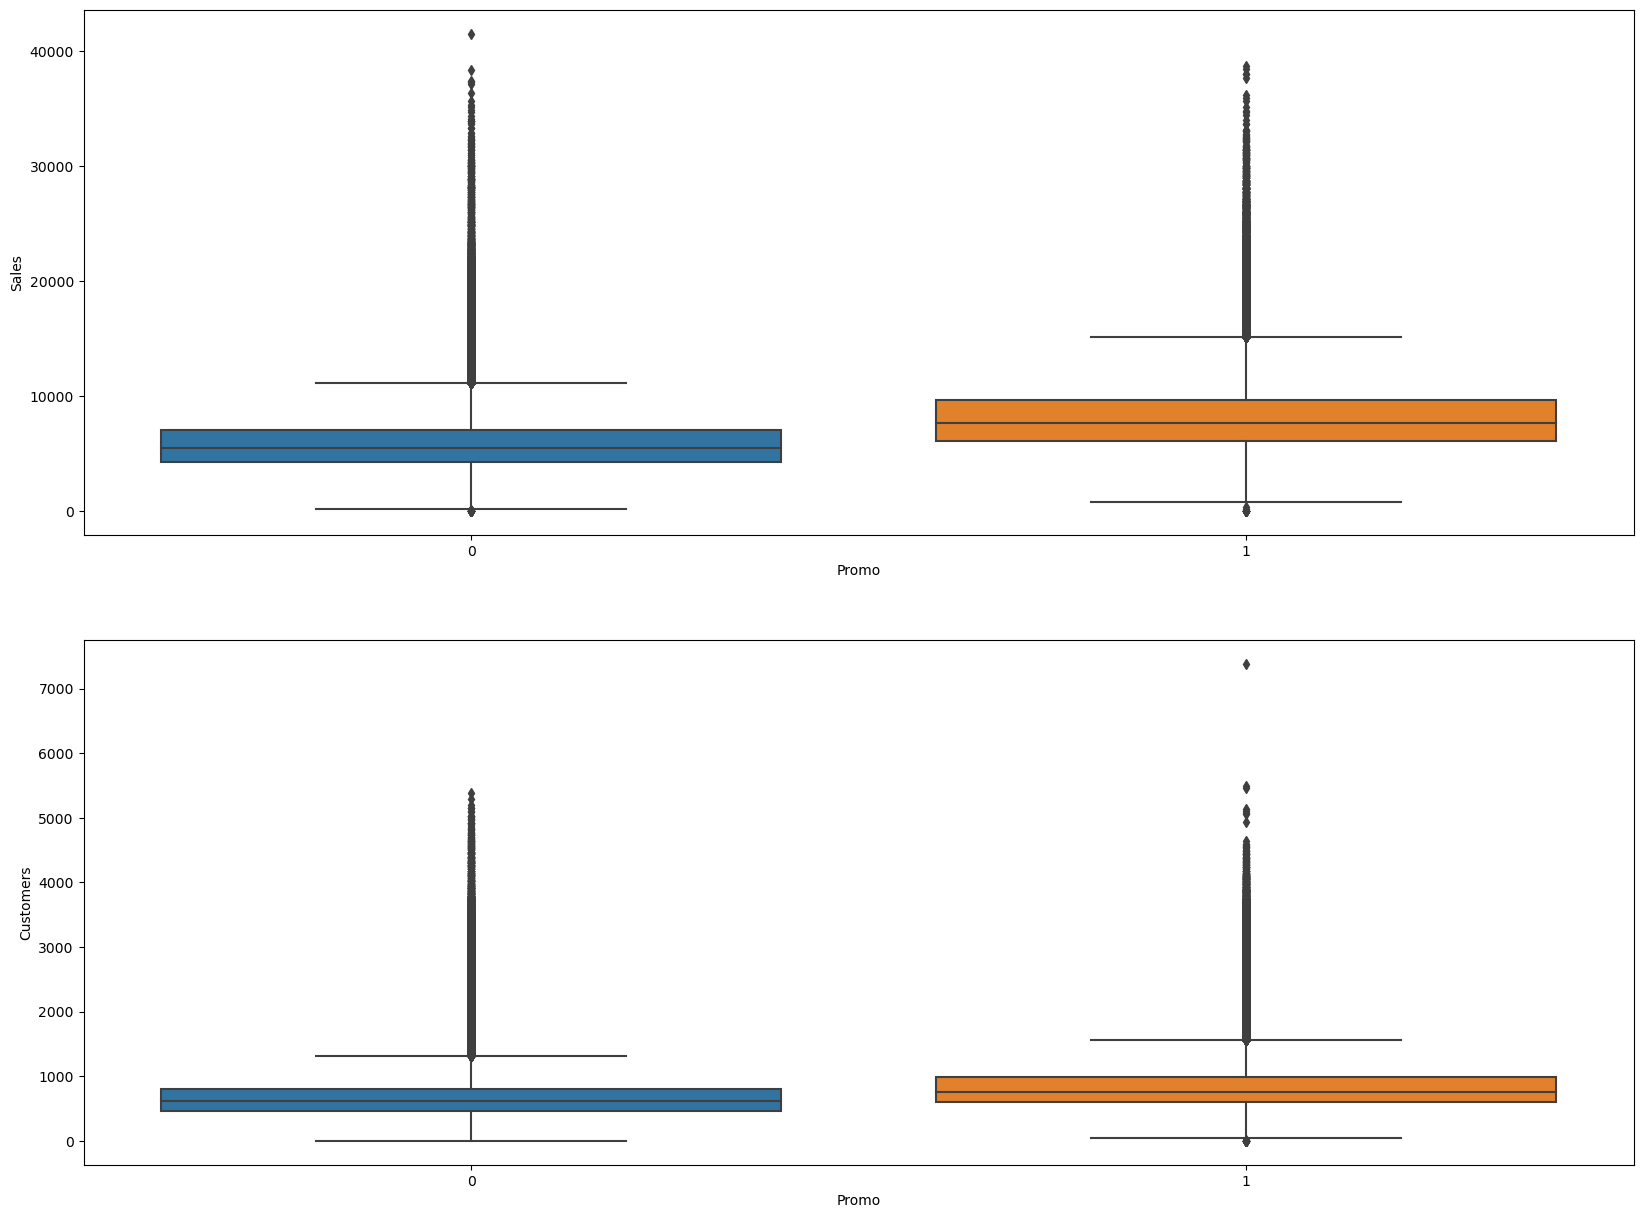

In [69]:
plt.figure(figsize=(20,15))
plt.subplot(211)
sns.boxplot(x='Promo', y='Sales', data=merged_df)
plt.subplot(212)
sns.boxplot(x='Promo', y='Customers', data= merged_df)
plt.show()


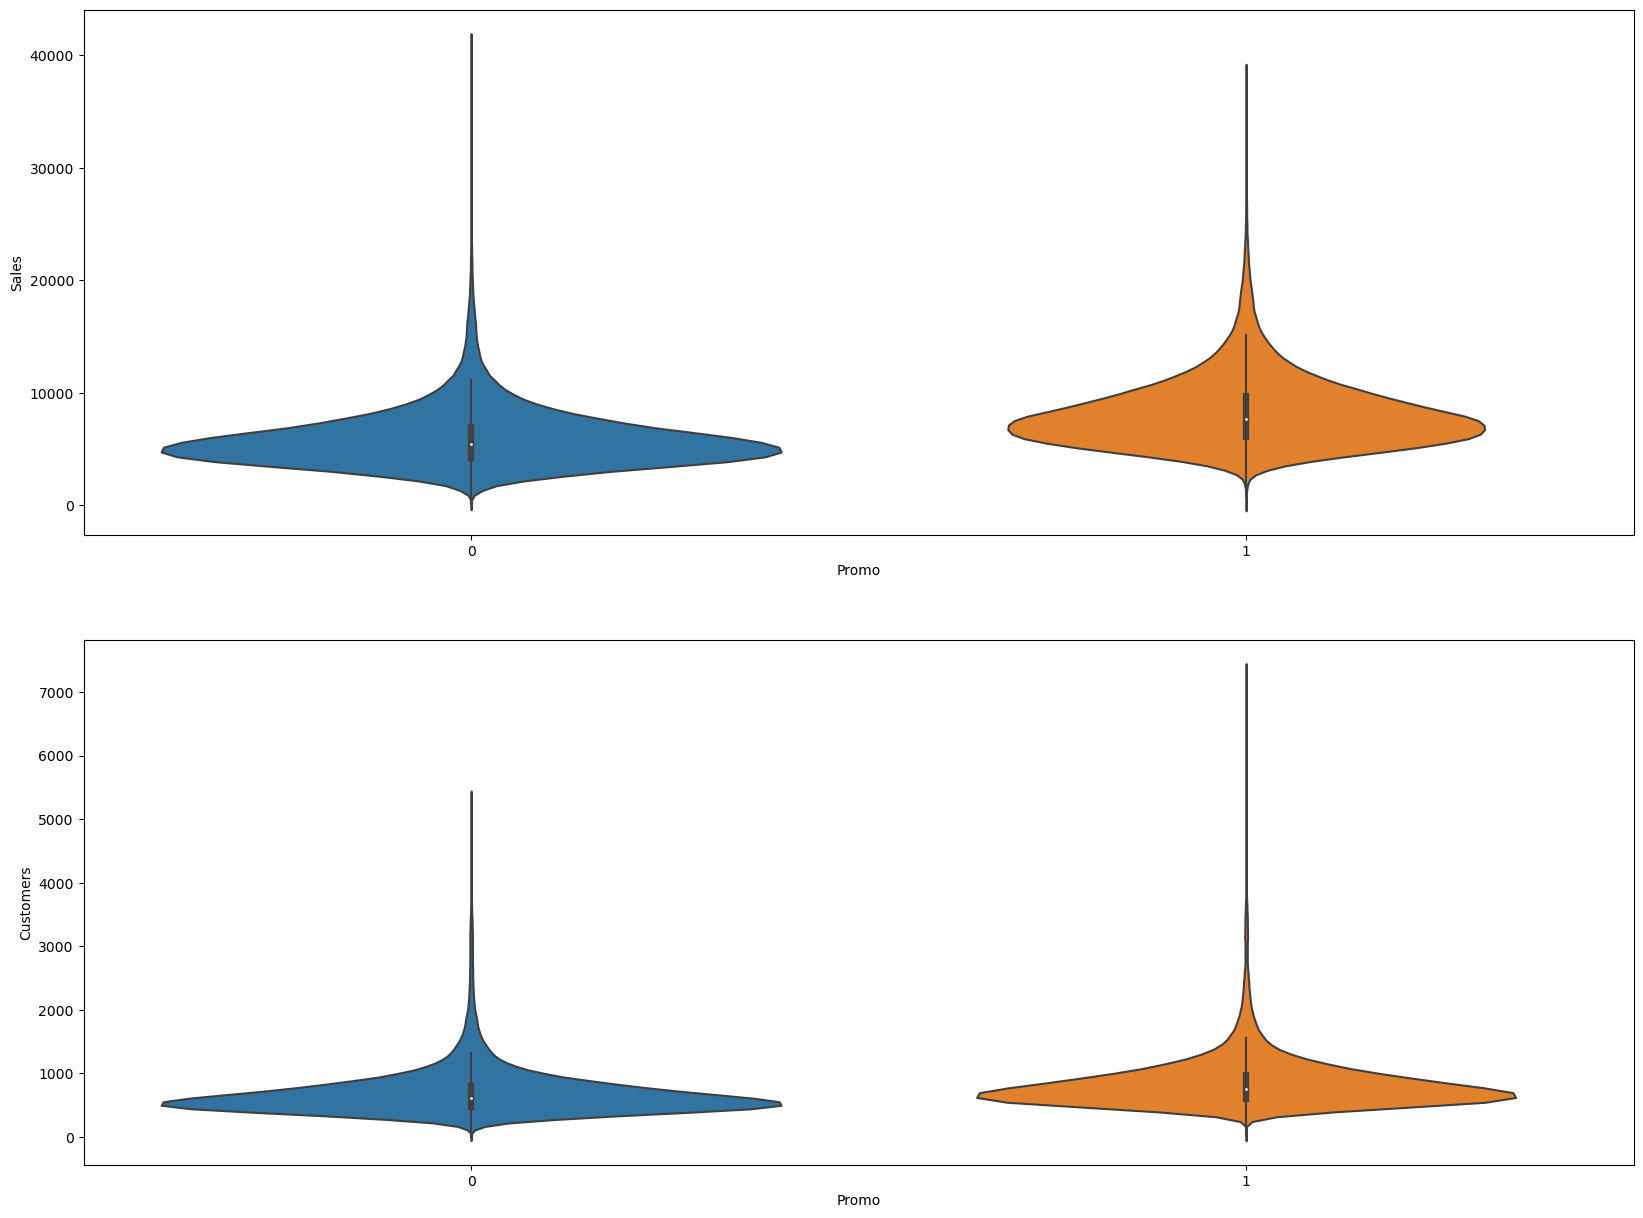

In [70]:
plt.figure(figsize=(20,15))
plt.subplot(211)
sns.violinplot(x='Promo', y='Sales', data=merged_df)
plt.subplot(212)
sns.violinplot(x='Promo', y='Customers', data= merged_df)
plt.show()


In [71]:
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

In [72]:
def sales_prediction(Store_ID, sales_df, periods):
    sales_df=sales_df[sales_df['Store']==Store_ID]
    sales_df=sales_df[['Date','Sales']].rename(columns={'Date':'ds', 'Sales':'y'})
    sales_df=sales_df.sort_values('ds')
    model=Prophet()
    model.fit(sales_df)
    future=model.make_future_dataframe(periods=periods)
    forecast=model.predict(future)
    figure1=model.plot(forecast, xlabel='Date', ylabel='Sales')
    figure2=model.plot_components(forecast)

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


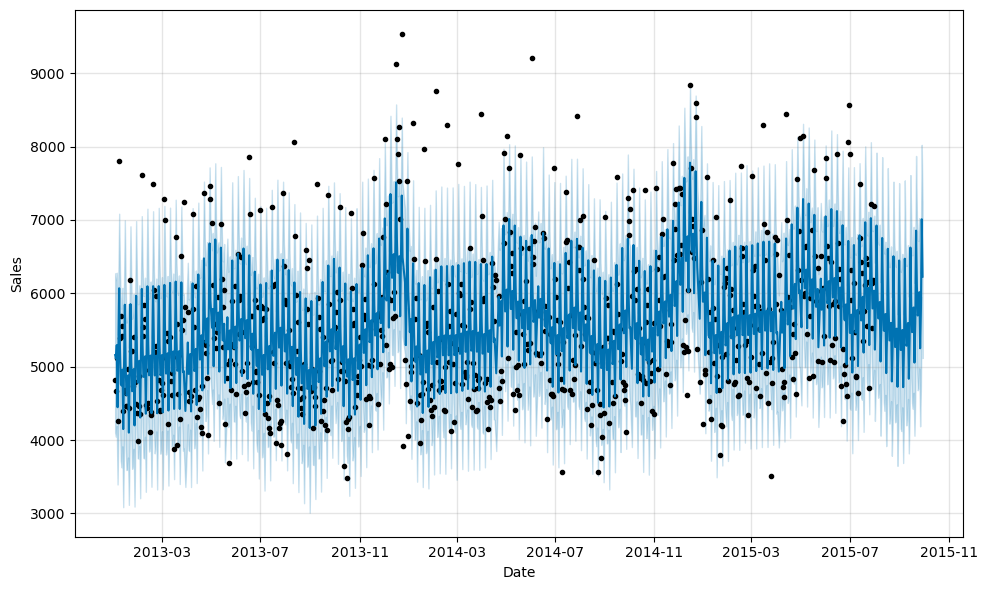

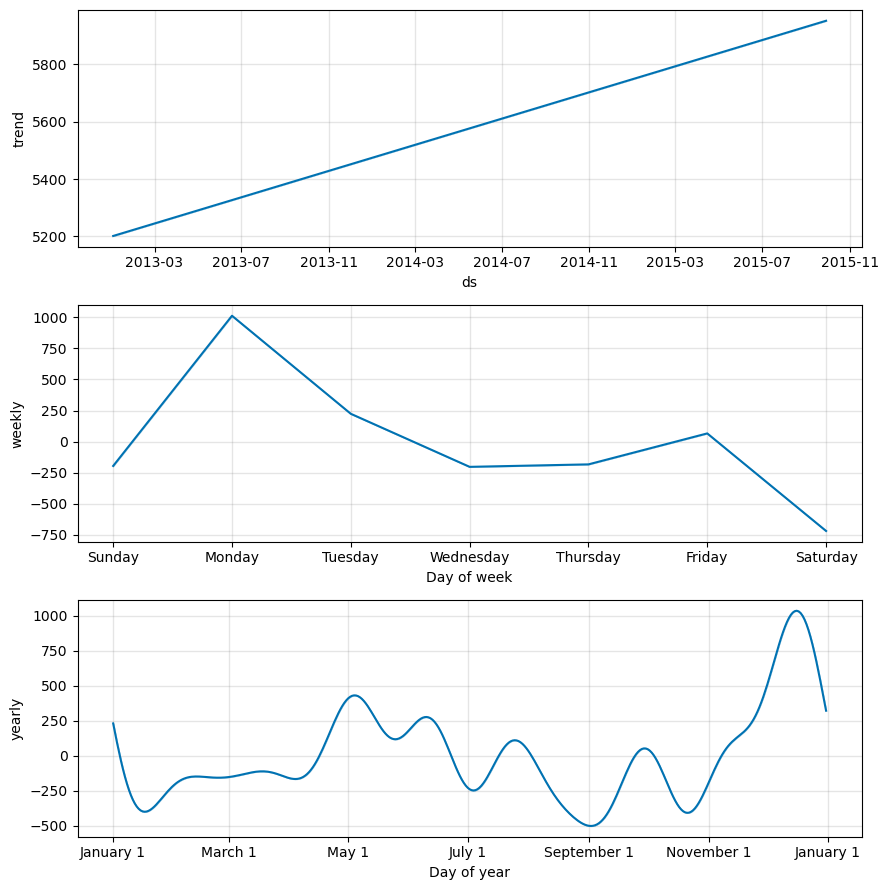

In [73]:
sales_prediction(10, merged_df, 60)

In [74]:
def sales_predictions(Store_ID, sales_df, holidays, periods):
    sales_df=sales_df[sales_df['Store']==Store_ID]
    sales_df=sales_df[['Date','Sales']].rename(columns={'Date':'ds', 'Sales':'y'})
    sales_df=sales_df.sort_values('ds')
    model=Prophet(holidays=holidays)
    model.fit(sales_df)
    future=model.make_future_dataframe(periods=periods)
    forecast=model.predict(future)
    figure1=model.plot(forecast, xlabel='Date', ylabel='Sales')
    figure2=model.plot_components(forecast)
    

In [75]:
school_holidays=merged_df[merged_df['SchoolHoliday']==1].loc[:,'Date'].values
school_holidays

array(['2015-07-31', '2015-07-30', '2015-07-29', ..., '2013-01-04',
       '2013-01-03', '2013-01-02'], dtype=object)

In [76]:
school_holidays.shape

(163457,)

In [77]:
state_holidays=merged_df[(merged_df['StateHoliday']=='a') | (merged_df['StateHoliday']=='b') | (merged_df['StateHoliday']=='c')].loc[:,'Date'].values
state_holidays

array(['2014-10-03', '2013-10-03', '2015-06-04', '2014-06-19',
       '2013-05-30', '2015-06-04', '2014-06-19', '2013-05-30',
       '2014-10-03', '2013-10-03', '2015-05-01', '2014-10-31',
       '2014-05-01', '2013-10-03', '2013-05-01', '2015-06-04',
       '2014-06-19', '2013-05-30', '2015-06-04', '2014-06-19',
       '2013-05-30', '2013-08-15', '2015-06-04', '2014-06-19',
       '2013-05-30', '2013-08-15', '2013-08-15', '2015-05-25',
       '2015-05-14', '2015-05-01', '2015-04-06', '2015-04-03',
       '2015-01-01', '2014-12-26', '2014-12-25', '2014-10-03',
       '2014-06-09', '2014-05-29', '2014-05-01', '2014-04-21',
       '2014-04-18', '2014-01-01', '2013-12-26', '2013-12-25',
       '2013-10-03', '2013-05-20', '2013-05-09', '2013-05-01',
       '2013-04-01', '2013-03-29', '2013-01-01', '2014-10-03',
       '2015-06-04', '2014-06-19', '2013-05-30', '2015-06-04',
       '2014-06-19', '2013-05-30', '2015-06-04', '2014-06-19',
       '2013-05-30', '2013-10-03', '2014-10-03', '2013-

In [78]:
state_holidays.shape

(910,)

In [79]:
state_holidays=pd.DataFrame({'ds': pd.to_datetime(state_holidays),
                               'holiday': 'state_holiday'})
state_holidays


,ds,holiday
0,2014-10-03,state_holiday
1,2013-10-03,state_holiday
2,2015-06-04,state_holiday
3,2014-06-19,state_holiday
4,2013-05-30,state_holiday
...,...,...
905,2013-04-01,state_holiday
906,2013-08-15,state_holiday
907,2015-06-04,state_holiday
908,2014-06-19,state_holiday


In [80]:
school_holidays=pd.DataFrame({'ds': pd.to_datetime(school_holidays),
                                'holiday': 'school_holiday'})
school_holidays


,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-30,school_holiday
2,2015-07-29,school_holiday
3,2015-07-28,school_holiday
4,2015-07-27,school_holiday
...,...,...
163452,2013-02-05,school_holiday
163453,2013-02-04,school_holiday
163454,2013-01-04,school_holiday
163455,2013-01-03,school_holiday


In [81]:
school_state_holidays=pd.concat((state_holidays, school_holidays))
school_state_holidays


,ds,holiday
0,2014-10-03,state_holiday
1,2013-10-03,state_holiday
2,2015-06-04,state_holiday
3,2014-06-19,state_holiday
4,2013-05-30,state_holiday
...,...,...
163452,2013-02-05,school_holiday
163453,2013-02-04,school_holiday
163454,2013-01-04,school_holiday
163455,2013-01-03,school_holiday


INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


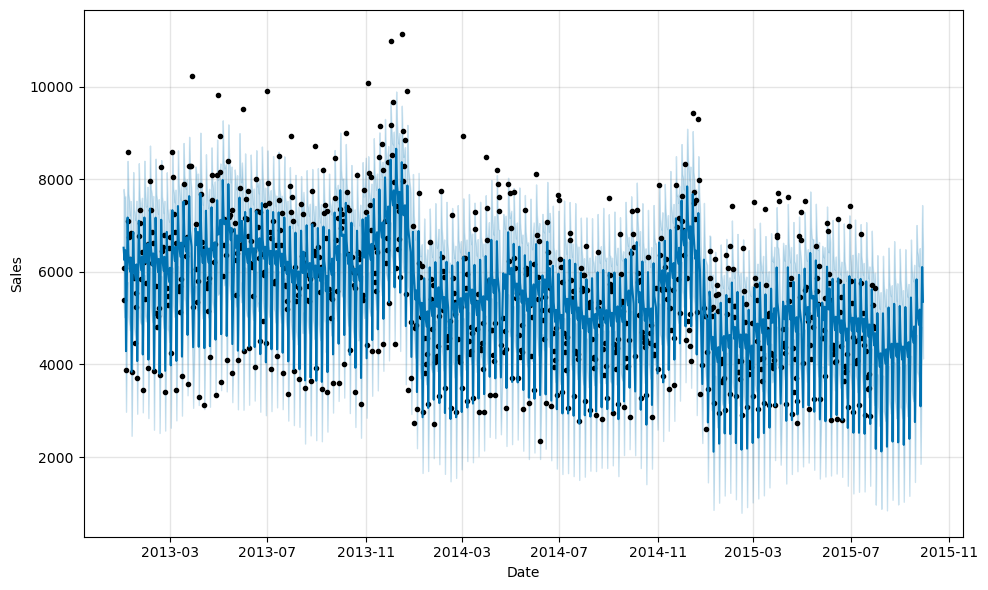

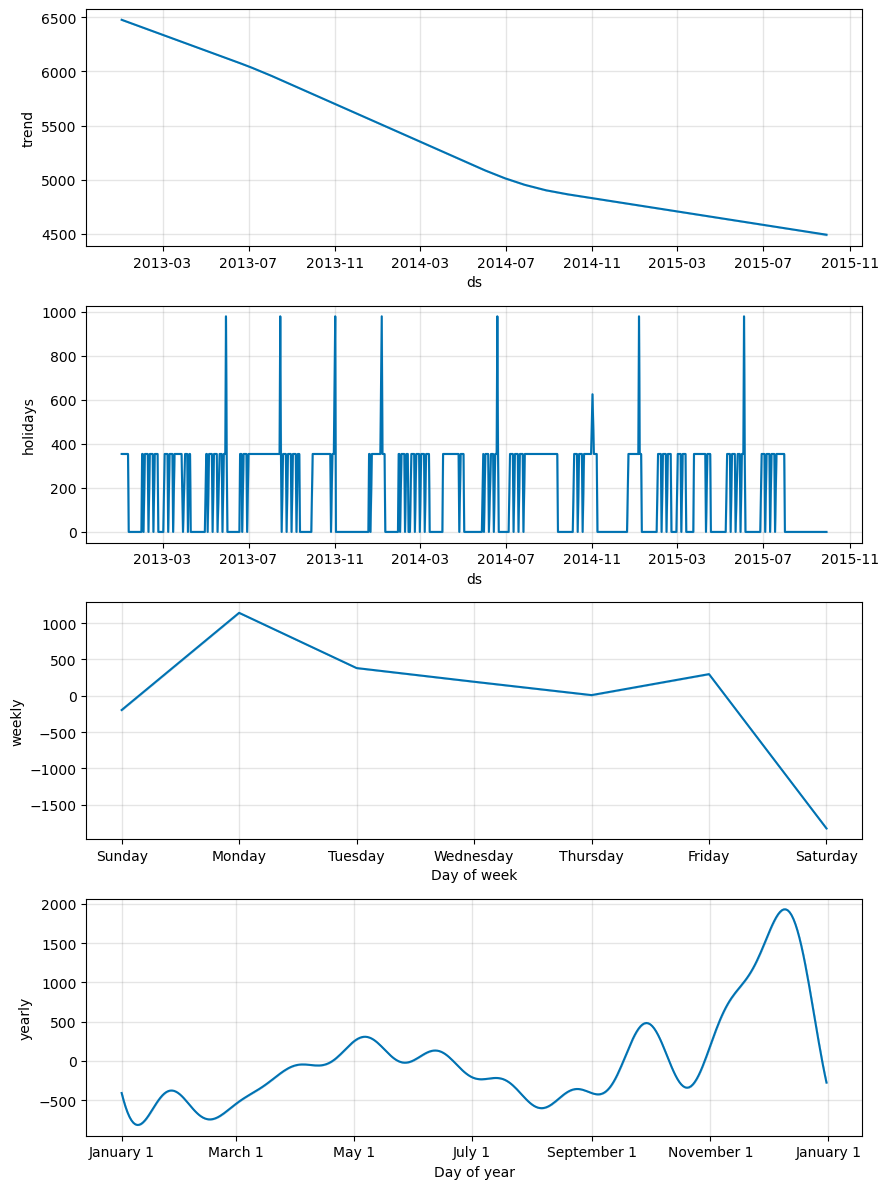

In [82]:
sales_predictions(6, merged_df, school_state_holidays, 60)

In [84]:
pip install scikit-learn


     ---------------------------------------- 7.1/7.1 MB 76.7 kB/s eta 0:00:00
     ------------------------------------ 302.2/302.2 kB 192.7 kB/s eta 0:00:00


In [91]:
def backtest_store(Store_ID, sales_df, holidays=None, test_days=60):
    store_df = sales_df[sales_df['Store'] == Store_ID][['Date', 'Sales']].rename(
        columns={'Date': 'ds', 'Sales': 'y'}
    ).sort_values('ds').reset_index(drop=True)
    
    store_df['ds'] = pd.to_datetime(store_df['ds'])
    
    train = store_df.iloc[:-test_days]
    test = store_df.iloc[-test_days:].copy()
    test['ds'] = pd.to_datetime(test['ds'])

    model = Prophet(holidays=holidays) if holidays is not None else Prophet()
    model.fit(train)

    future = model.make_future_dataframe(periods=test_days)
    forecast = model.predict(future)

    merged = test.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
    
    actual_test = merged['y'].values
    forecast_test = merged['yhat'].values

    mae = mean_absolute_error(actual_test, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual_test, forecast_test))
    mape = np.mean(np.abs((actual_test - forecast_test) / actual_test)) * 100

    print(f'Store {Store_ID} - held-out last {test_days} days')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAPE: {mape:.2f}%')
    
    if len(merged) < len(test):
        print(f"Warning: Merged length ({len(merged)}) is less than test length ({len(test)}).")

    return mae, rmse, mape, forecast, test

In [92]:
mae, rmse, mape, forecast, test = backtest_store(6, merged_df, school_state_holidays, test_days=60)

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Store 6 - held-out last 60 days
MAE: 752.87
RMSE: 916.48
MAPE: 16.55%


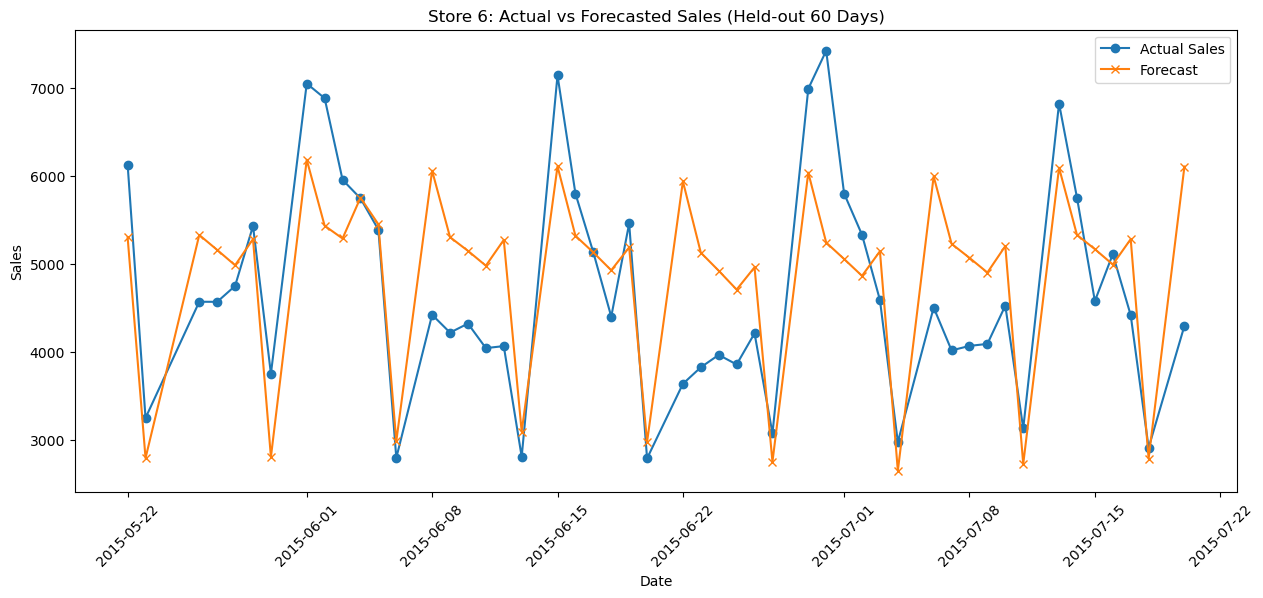

In [94]:
merged_df = pd.merge(test, forecast, on='ds', how='inner')

plt.figure(figsize=(15, 6))
plt.plot(merged_df['ds'], merged_df['y'], label='Actual Sales', marker='o')
plt.plot(merged_df['ds'], merged_df['yhat'], label='Forecast', marker='x')
plt.title('Store 6: Actual vs Forecasted Sales (Held-out 60 Days)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()